In [ ]:
import os, sys
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [21]:

# =============================
# 0) 경로
# =============================
FILE_PATH_TRAIN = "/Users/bagjimin/Desktop/LG_HelloVision/PROJECT/개선시도/data/churn_segment_fingal.parquet"
FILE_PATH_TEST  = "/Users/bagjimin/Desktop/LG_HelloVision/PROJECT/개선시도/data/churn_segment_nov_only.parquet"

# =============================
# 1) 데이터 로드
# =============================
df_train = pd.read_parquet(FILE_PATH_TRAIN)
df_test  = pd.read_parquet(FILE_PATH_TEST)

print("✅ Loaded")
print(" - train:", df_train.shape, "| columns:", len(df_train.columns))
print(" - test :", df_test.shape,  "| columns:", len(df_test.columns))

✅ Loaded
 - train: (2003126, 9) | columns: 9
 - test : (1998550, 9) | columns: 9


In [22]:

# =============================
# 2) 타겟/ID 컬럼 체크
# =============================
TARGET_COL = "label"
ID_COL = "sha2_hash"

if TARGET_COL not in df_train.columns:
    raise ValueError(f"[train] '{TARGET_COL}' 컬럼이 없습니다.")
if TARGET_COL not in df_test.columns:
    raise ValueError(f"[test] '{TARGET_COL}' 컬럼이 없습니다.")
if ID_COL not in df_train.columns:
    print(f"⚠️ [train] '{ID_COL}' 컬럼이 없습니다. (ID 없이 진행)")
if ID_COL not in df_test.columns:
    print(f"⚠️ [test] '{ID_COL}' 컬럼이 없습니다. (ID 없이 진행)")

In [ ]:

# =============================
# 3) X/y 분리
#    - train: train 파일 그대로 학습용(내부에서 stratified split)
#    - test : nov_only 파일은 최종 검증용으로 사용
# =============================
DROP_COLS = [TARGET_COL]
if ID_COL in df_train.columns: DROP_COLS.append(ID_COL)
if "p_mt" in df_train.columns: DROP_COLS.append("p_mt")  # 있으면 제거

X_full = df_train.drop(columns=[c for c in DROP_COLS if c in df_train.columns]).copy()
y_full = df_train[TARGET_COL].copy()

X_test = df_test.drop(columns=[c for c in DROP_COLS if c in df_test.columns]).copy()
y_test = df_test[TARGET_COL].copy()

In [40]:

# =============================
# 4) train/val split (훈련 파일 내부에서)
# =============================
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=42
)

print("\n📌 Split")

acc = accuracy_score(y_test_small, y_pred)
f1  = f1_score(y_test_small, y_pred)
rec = recall_score(y_test_small, y_pred)
prec = precision_score(y_test_small, y_pred, zero_division=0)


print(" - X_train:", X_train.shape, "y_train:", y_train.shape)
print(" - X_val  :", X_val.shape,   "y_val  :", y_val.shape)
print(" - X_test :", X_test.shape,  "y_test :", y_test.shape)



📌 Split
 - X_train: (1602500, 6) y_train: (1602500,)
 - X_val  : (400626, 6) y_val  : (400626,)
 - X_test : (1998550, 6) y_test : (1998550,)


In [25]:

# =============================
# 5) [핵심] train/test 컬럼 정렬 (ColumnTransformer 쓰더라도 안전장치)
#    - test에만 있는 컬럼 제거
#    - train에만 있는 컬럼은 test에 0으로 생성
# =============================
train_cols = X_train.columns

X_val  = X_val.reindex(columns=train_cols, fill_value=0)
X_test = X_test.reindex(columns=train_cols, fill_value=0)

In [ ]:

# =============================
# 6) Light Mode 샘플링
# =============================
SAMPLE_RATIO = 0.1

X_train_small = X_train.sample(frac=SAMPLE_RATIO, random_state=42)
y_train_small = y_train.loc[X_train_small.index]

X_test_small = X_test.sample(frac=SAMPLE_RATIO, random_state=42)
y_test_small = y_test.loc[X_test_small.index]

print(f"\n📉 [Light Mode] 샘플링 ({SAMPLE_RATIO*100:.0f}%)")
print(f" - Train: {len(X_train):,} -> {len(X_train_small):,}")
print(f" - Test : {len(X_test):,} -> {len(X_test_small):,}")


📉 [Light Mode] 샘플링 (10%)
 - Train: 1,602,500 -> 160,250
 - Test : 1,998,550 -> 199,855


In [29]:

# =============================
# 7) 전처리 파이프라인
# =============================
numeric_features = X_train_small.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns
categorical_features = X_train_small.select_dtypes(include=["object", "category", "bool"]).columns

print(f"\n🔢 numeric({len(numeric_features)})")
print(f"🔤 categorical({len(categorical_features)})")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop"
)


🔢 numeric(4)
🔤 categorical(2)


In [35]:
# =============================
# 8) 모델 정의 (경량 비교용)
# =============================
models = {
    "LogisticRegression": LogisticRegression(random_state=42, max_iter=500, n_jobs=-1, class_weight='balanced'),
    "DecisionTree": DecisionTreeClassifier(random_state=42, max_depth=10, class_weight='balanced'),
    "RandomForest": RandomForestClassifier(random_state=42, n_estimators=50, max_depth=10, n_jobs=-1, class_weight='balanced'),
    "LGBM": LGBMClassifier(random_state=42, n_estimators=50, max_depth=10, verbose=-1, n_jobs=-1, class_weight='balanced'),
    "XGBoost": XGBClassifier(
        random_state=42,
        n_estimators=50,
        max_depth=10,
        eval_metric="logloss",
        n_jobs=-1,
        class_weight='balanced'
    ),
}

In [ ]:

# =============================
# 9) 학습/평가 루프 (Recall 중심)
# =============================
results = []
print("\n🚀 [Recall 기준] 알고리즘 비교 시작 (Light Mode)")
print("=" * 70)

for name, model in models.items():
    print(f"Training {name}...", end=" ")

    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    clf.fit(X_train_small, y_train_small)

    y_pred = clf.predict(X_test_small)

    # ROC-AUC (proba 있으면 사용)
    if hasattr(clf, "predict_proba"):
        y_prob = clf.predict_proba(X_test_small)[:, 1]
        roc = roc_auc_score(y_test_small, y_prob)
    else:
        roc = np.nan

    acc = accuracy_score(y_test_small, y_pred)
    f1  = f1_score(y_test_small, y_pred)
    rec = recall_score(y_test_small, y_pred)

    print(f"-> 완료 (Recall: {rec:.4f})")

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "F1 Score": f1,
        "Recall": rec,
        "ROC AUC": roc
    })
print("=" * 70)
print("✅ 비교 완료!")

results_df = pd.DataFrame(results).sort_values(by="Recall", ascending=False)
display(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_recall = results_df.iloc[0]["Recall"]
print(f"\n🏆 Best Recall Model: {best_model_name} (Recall: {best_recall:.4f})")


🚀 [Recall 기준] 알고리즘 비교 시작 (Light Mode)
Training LogisticRegression... 

ValueError: Found input variables with inconsistent numbers of samples: [199855, 1998550]

In [42]:
import os, sys
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, recall_score, precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# =============================
# 0) 경로
# =============================
FILE_PATH_TRAIN = "/Users/bagjimin/Desktop/LG_HelloVision/PROJECT/개선시도/data/churn_segment_fingal.parquet"
FILE_PATH_TEST  = "/Users/bagjimin/Desktop/LG_HelloVision/PROJECT/개선시도/data/churn_segment_nov_only.parquet"

# =============================
# 1) 데이터 로드
# =============================
df_train = pd.read_parquet(FILE_PATH_TRAIN)
df_test  = pd.read_parquet(FILE_PATH_TEST)

print("✅ Loaded")
print(" - train:", df_train.shape, "| columns:", len(df_train.columns))
print(" - test :", df_test.shape,  "| columns:", len(df_test.columns))

# =============================
# 2) 타겟/ID 컬럼 체크
# =============================
TARGET_COL = "label"
ID_COL = "sha2_hash"

if TARGET_COL not in df_train.columns:
    raise ValueError(f"[train] '{TARGET_COL}' 컬럼이 없습니다.")
if TARGET_COL not in df_test.columns:
    raise ValueError(f"[test] '{TARGET_COL}' 컬럼이 없습니다.")

# =============================
# 3) X/y 분리
# =============================
drop_cols = [TARGET_COL]
if ID_COL in df_train.columns: drop_cols.append(ID_COL)
if "p_mt" in df_train.columns: drop_cols.append("p_mt")

X_full = df_train.drop(columns=[c for c in drop_cols if c in df_train.columns]).copy()
y_full = df_train[TARGET_COL].copy()

X_test = df_test.drop(columns=[c for c in drop_cols if c in df_test.columns]).copy()
y_test = df_test[TARGET_COL].copy()

# =============================
# 4) train/val split (train 파일 내부에서)
# =============================
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=42
)

print("\n📌 Split")
print(" - X_train:", X_train.shape, "y_train:", y_train.shape)
print(" - X_val  :", X_val.shape,   "y_val  :", y_val.shape)
print(" - X_test :", X_test.shape,  "y_test :", y_test.shape)

# imbalance 비율 (XGB scale_pos_weight)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)
print(f"\n⚖️ train neg/pos = {neg:,}/{pos:,} | scale_pos_weight={scale_pos_weight:.3f}")

# =============================
# 5) train 기준 컬럼 정렬 (안전장치)
# =============================
train_cols = X_train.columns
X_val  = X_val.reindex(columns=train_cols, fill_value=0)
X_test = X_test.reindex(columns=train_cols, fill_value=0)

# =============================
# 6) Light Mode 샘플링
# =============================
SAMPLE_RATIO = 0.1

X_train_small = X_train.sample(frac=SAMPLE_RATIO, random_state=42)
y_train_small = y_train.loc[X_train_small.index]

X_test_small = X_test.sample(frac=SAMPLE_RATIO, random_state=42)
y_test_small = y_test.loc[X_test_small.index]

print(f"\n📉 [Light Mode] 샘플링 ({SAMPLE_RATIO*100:.0f}%)")
print(f" - Train: {len(X_train):,} -> {len(X_train_small):,}")
print(f" - Test : {len(X_test):,} -> {len(X_test_small):,}")

# =============================
# 7) 전처리 파이프라인
# =============================
numeric_features = X_train_small.select_dtypes(include=["int64","float64","int32","float32"]).columns
categorical_features = X_train_small.select_dtypes(include=["object","category","bool"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop"
)

# =============================
# 8) 모델 정의
#   - sklearn 계열: class_weight
#   - xgboost: scale_pos_weight
# =============================
models = {
    "LogisticRegression": LogisticRegression(
        random_state=42, max_iter=500, n_jobs=-1, class_weight="balanced"
    ),
    "DecisionTree": DecisionTreeClassifier(
        random_state=42, max_depth=10, class_weight="balanced"
    ),
    "RandomForest": RandomForestClassifier(
        random_state=42, n_estimators=50, max_depth=10, n_jobs=-1, class_weight="balanced"
    ),
    "LGBM": LGBMClassifier(
        random_state=42, n_estimators=50, max_depth=10, verbose=-1, n_jobs=-1,
        class_weight={0:1, 1:scale_pos_weight}
    ),
    "XGBoost": XGBClassifier(
        random_state=42, n_estimators=50, max_depth=10, eval_metric="logloss", n_jobs=-1,
        scale_pos_weight=scale_pos_weight
    ),
}

# =============================
# 9) 학습/평가 루프 (Recall + Precision)
# =============================
results = []
print("\n🚀 [Recall 기준] 알고리즘 비교 시작 (Light Mode)")
print("=" * 70)

for name, model in models.items():
    print(f"Training {name}...", end=" ")

    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    clf.fit(X_train_small, y_train_small)
    y_pred = clf.predict(X_test_small)

    # ROC-AUC (proba 있으면 사용)
    if hasattr(clf, "predict_proba"):
        y_prob = clf.predict_proba(X_test_small)[:, 1]
        roc = roc_auc_score(y_test_small, y_prob)
    else:
        roc = np.nan

    acc  = accuracy_score(y_test_small, y_pred)
    f1   = f1_score(y_test_small, y_pred, zero_division=0)
    rec  = recall_score(y_test_small, y_pred, zero_division=0)
    prec = precision_score(y_test_small, y_pred, zero_division=0)

    print(f"-> 완료 (Recall: {rec:.4f}, Precision: {prec:.4f})")

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC AUC": roc
    })

print("=" * 70)
print("✅ 비교 완료!")

results_df = pd.DataFrame(results).sort_values(by=["Recall","Precision"], ascending=False)
display(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_recall = results_df.iloc[0]["Recall"]
best_prec = results_df.iloc[0]["Precision"]
print(f"\n🏆 Best Model: {best_model_name} | Recall={best_recall:.4f} | Precision={best_prec:.4f}")


✅ Loaded
 - train: (2003126, 9) | columns: 9
 - test : (1998550, 9) | columns: 9

📌 Split
 - X_train: (1602500, 6) y_train: (1602500,)
 - X_val  : (400626, 6) y_val  : (400626,)
 - X_test : (1998550, 6) y_test : (1998550,)

⚖️ train neg/pos = 1,547,851/54,649 | scale_pos_weight=28.324

📉 [Light Mode] 샘플링 (10%)
 - Train: 1,602,500 -> 160,250
 - Test : 1,998,550 -> 199,855

🚀 [Recall 기준] 알고리즘 비교 시작 (Light Mode)
Training LogisticRegression... -> 완료 (Recall: 0.7013, Precision: 0.0208)
Training DecisionTree... -> 완료 (Recall: 0.5688, Precision: 0.0264)
Training RandomForest... -> 완료 (Recall: 0.5424, Precision: 0.0285)
Training LGBM... -> 완료 (Recall: 0.5749, Precision: 0.0272)
Training XGBoost... -> 완료 (Recall: 0.5337, Precision: 0.0263)
✅ 비교 완료!


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,LogisticRegression,0.539526,0.020797,0.701303,0.040395,0.665452
3,LGBM,0.710330,0.027236,0.574946,0.052008,0.686215
1,DecisionTree,0.704601,0.026440,0.568791,0.050532,0.672457
2,RandomForest,0.738490,0.028534,0.542361,0.054216,0.683968
4,XGBoost,0.720718,0.026320,0.533671,0.050167,0.657620



🏆 Best Model: LogisticRegression | Recall=0.7013 | Precision=0.0208


In [46]:
import os, sys
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, recall_score, precision_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# =============================
# 0) 경로
# =============================
FILE_PATH_TRAIN = "/Users/bagjimin/Desktop/LG_HelloVision/PROJECT/개선시도/data/churn_segment_fingal.parquet"
FILE_PATH_TEST  = "/Users/bagjimin/Desktop/LG_HelloVision/PROJECT/개선시도/data/churn_segment_nov_only.parquet"

# =============================
# 1) 데이터 로드
# =============================
df_train = pd.read_parquet(FILE_PATH_TRAIN)
df_test  = pd.read_parquet(FILE_PATH_TEST)

print("✅ Loaded")
print(" - train:", df_train.shape, "| columns:", len(df_train.columns))
print(" - test :", df_test.shape,  "| columns:", len(df_test.columns))

# =============================
# 2) 타겟/ID 컬럼 체크
# =============================
TARGET_COL = "label"
ID_COL = "sha2_hash"

if TARGET_COL not in df_train.columns:
    raise ValueError(f"[train] '{TARGET_COL}' 컬럼이 없습니다.")
if TARGET_COL not in df_test.columns:
    raise ValueError(f"[test] '{TARGET_COL}' 컬럼이 없습니다.")

# =============================
# 3) X/y 분리
# =============================
drop_cols = [TARGET_COL]
if ID_COL in df_train.columns: drop_cols.append(ID_COL)
if "p_mt" in df_train.columns: drop_cols.append("p_mt")

X_full = df_train.drop(columns=[c for c in drop_cols if c in df_train.columns]).copy()
y_full = df_train[TARGET_COL].copy()

X_test = df_test.drop(columns=[c for c in drop_cols if c in df_test.columns]).copy()
y_test = df_test[TARGET_COL].copy()

# =============================
# 4) train/val split (train 파일 내부에서)
# =============================
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=42
)

print("\n📌 Split")
print(" - X_train:", X_train.shape, "y_train:", y_train.shape)
print(" - X_val  :", X_val.shape,   "y_val  :", y_val.shape)
print(" - X_test :", X_test.shape,  "y_test :", y_test.shape)

# imbalance 비율 (XGB scale_pos_weight)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)
print(f"\n⚖️ train neg/pos = {neg:,}/{pos:,} | scale_pos_weight={scale_pos_weight:.3f}")

# =============================
# 5) train 기준 컬럼 정렬 (안전장치)
# =============================
train_cols = X_train.columns
X_val  = X_val.reindex(columns=train_cols, fill_value=0)
X_test = X_test.reindex(columns=train_cols, fill_value=0)

# =============================
# 6) 전처리 파이프라인
# =============================
numeric_features = X_train.select_dtypes(include=["int64","float64","int32","float32"]).columns
categorical_features = X_train.select_dtypes(include=["object","category","bool"]).columns

print(f"\n🔢 numeric({len(numeric_features)})")
print(f"🔤 categorical({len(categorical_features)})")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop"
)

# =============================
# 7) 모델 정의 (경량 비교용: 샘플링 대신 모델만 경량화)
#   - sklearn 계열: class_weight="balanced"
#   - xgboost: scale_pos_weight
# =============================
models = {
    "LogisticRegression": LogisticRegression(
        random_state=42, max_iter=500, n_jobs=-1, class_weight="balanced"
    ),
    "DecisionTree": DecisionTreeClassifier(
        random_state=42, max_depth=10, class_weight="balanced"
    ),
    "RandomForest": RandomForestClassifier(
        random_state=42, n_estimators=80, max_depth=10, n_jobs=-1, class_weight="balanced"
    ),
    "LGBM": LGBMClassifier(
        random_state=42, n_estimators=120, max_depth=10, verbose=-1, n_jobs=-1,
        class_weight={0:1, 1:scale_pos_weight}
    ),
    "XGBoost": XGBClassifier(
        random_state=42, n_estimators=120, max_depth=10, eval_metric="logloss", n_jobs=-1,
        scale_pos_weight=scale_pos_weight
    ),
}

# =============================
# 8) 학습/평가 루프 (Test 기준: nov_only 파일)
# =============================
results = []
print("\n🚀 [Recall 기준] 알고리즘 비교 시작 (No Sampling)")
print("=" * 70)

for name, model in models.items():
    print(f"Training {name}...", end=" ")

    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    # ROC-AUC (proba 있으면 사용)
    if hasattr(clf, "predict_proba"):
        # y_prob = clf.predict_proba(X_test)[:, 1]
        y_prob = clf.predict_proba(X_test)[:,1]

        roc = roc_auc_score(y_test, y_prob)
    else:
        roc = np.nan

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)

    print(f"-> 완료 (Recall: {rec:.4f}, Precision: {prec:.4f})")

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC AUC": roc
    })

print("=" * 70)
print("✅ 비교 완료!")

results_df = pd.DataFrame(results).sort_values(by=["Recall","Precision"], ascending=False)
display(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_recall = results_df.iloc[0]["Recall"]
best_prec = results_df.iloc[0]["Precision"]
print(f"\n🏆 Best Model: {best_model_name} | Recall={best_recall:.4f} | Precision={best_prec:.4f}")


✅ Loaded
 - train: (2003126, 9) | columns: 9
 - test : (1998550, 9) | columns: 9

📌 Split
 - X_train: (1602500, 6) y_train: (1602500,)
 - X_val  : (400626, 6) y_val  : (400626,)
 - X_test : (1998550, 6) y_test : (1998550,)

⚖️ train neg/pos = 1,547,851/54,649 | scale_pos_weight=28.324

🔢 numeric(4)
🔤 categorical(2)

🚀 [Recall 기준] 알고리즘 비교 시작 (No Sampling)
Training LogisticRegression... -> 완료 (Recall: 0.6816, Precision: 0.0212)
Training DecisionTree... -> 완료 (Recall: 0.5829, Precision: 0.0269)
Training RandomForest... -> 완료 (Recall: 0.5675, Precision: 0.0277)
Training LGBM... -> 완료 (Recall: 0.5839, Precision: 0.0270)
Training XGBoost... -> 완료 (Recall: 0.5547, Precision: 0.0272)
✅ 비교 완료!


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,LogisticRegression,0.555498,0.021189,0.681608,0.041099,0.661939
3,LGBM,0.700602,0.027043,0.583867,0.051691,0.690309
1,DecisionTree,0.699313,0.026885,0.582901,0.051400,0.686080
2,RandomForest,0.715460,0.027689,0.567470,0.052801,0.689950
4,XGBoost,0.716993,0.027245,0.554688,0.051939,0.673975



🏆 Best Model: LogisticRegression | Recall=0.6816 | Precision=0.0212


In [47]:
print("Actual churn rate:", y_test.mean())


Actual churn rate: 0.013975632333441745


In [48]:
print("Base rate:", y_test.mean())

print("Max prob:", y_prob.max())
print("Mean prob:", y_prob.mean())

pd.Series(y_prob).describe()


Base rate: 0.013975632333441745
Max prob: 0.9609862
Mean prob: 0.43450356


count    1.998550e+06
mean     4.345036e-01
std      1.545396e-01
min      1.234814e-05
25%      3.318125e-01
50%      4.086368e-01
75%      5.284070e-01
max      9.609862e-01
dtype: float64

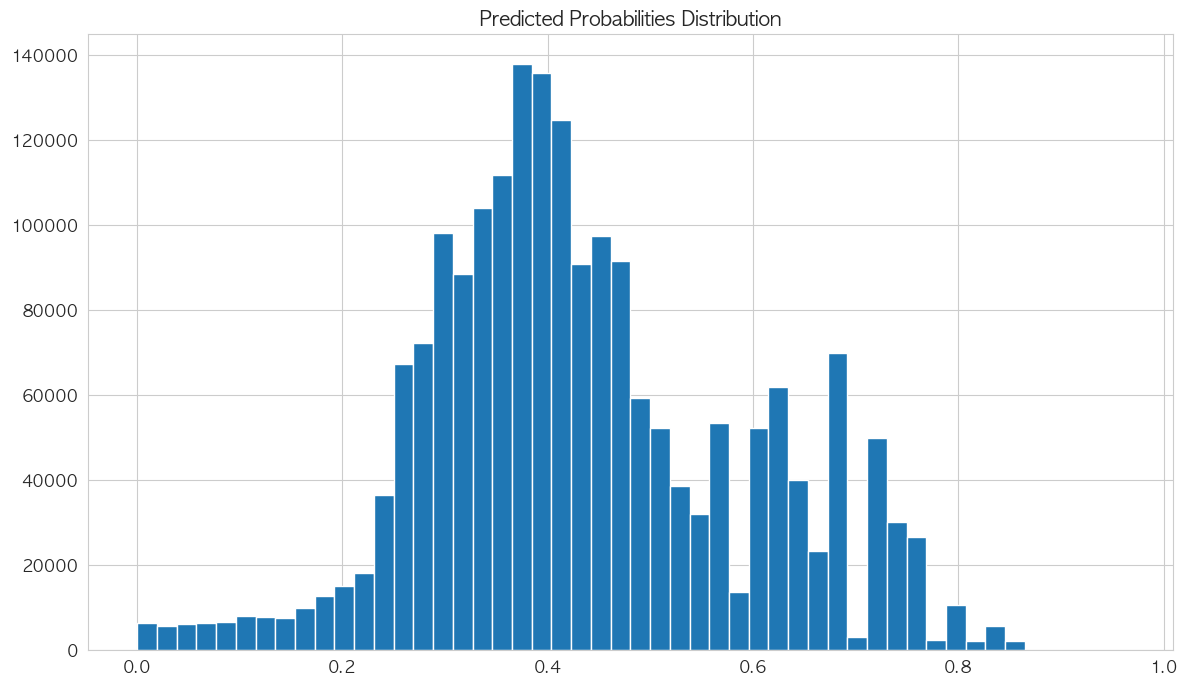

In [49]:
import matplotlib.pyplot as plt

plt.hist(y_prob, bins=50)
plt.title("Predicted Probabilities Distribution")
plt.show()
